In [8]:
import torch
import torchvision
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt
import numpy as np
import cv2
from einops import rearrange
from PIL import Image

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Loading the Oxford-IIIT Pets Dataset

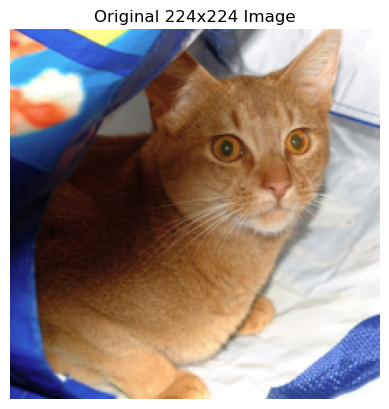

In [9]:
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
])

dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', transform=transform, download=True)

img_tensor, label = dataset[0] # Picking an image of a pet

def show_image(tensor, title=None):
    img = tensor.permute(1, 2, 0).numpy()
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

show_image(img_tensor, title="Original 224x224 Image")

## 2. The Patches

Original shape: torch.Size([3, 224, 224])
Patches shape: torch.Size([196, 3, 16, 16]) -> (Number of Patches, Channels, Patch_H, Patch_W)


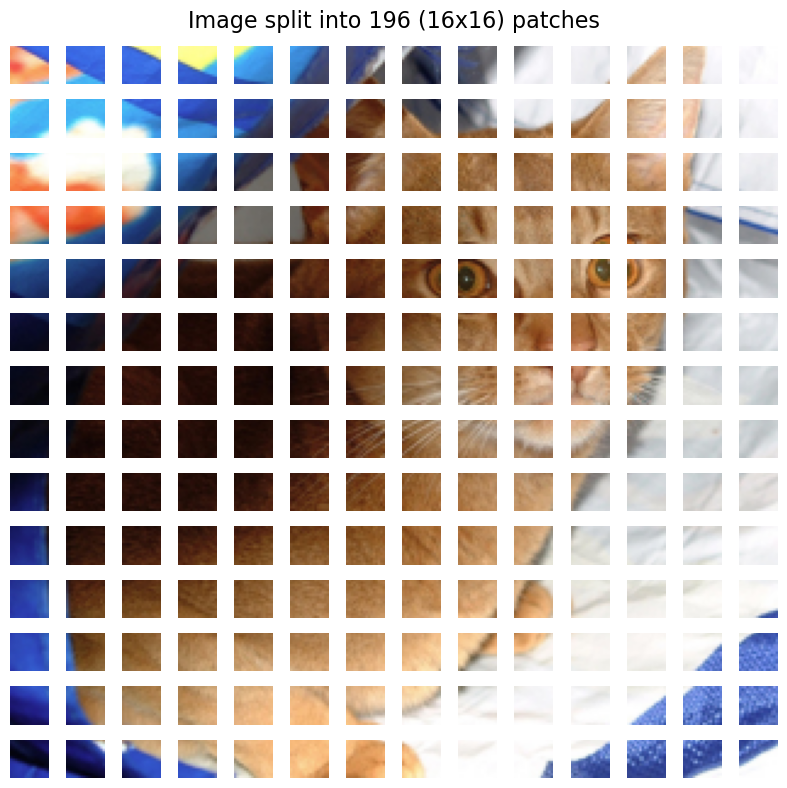

In [10]:
patch_size = 16

# c: channels, h & w: height & width, p1 & p2: patch dimensions
patches = rearrange(img_tensor, 'c (h p1) (w p2) -> (h w) c p1 p2', p1=patch_size, p2=patch_size)

print(f"Original shape: {img_tensor.shape}")
print(f"Patches shape: {patches.shape} -> (Number of Patches, Channels, Patch_H, Patch_W)")

fig, axes = plt.subplots(14, 14, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    patch_img = patches[i].permute(1, 2, 0).numpy()
    ax.imshow(patch_img)
    ax.axis('off')
plt.suptitle("Image split into 196 (16x16) patches", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Pre-trained ViT & Extracting Attention
Training a ViT from scratch requires massive datasets. For this project, I am using a pre-trained `vit_base_patch16_224` from the `timm` library. 

To see what the model is focusing on, I will use a PyTorch **forward hook** to intercept the attention weights from the final transformer block before they are passed to the classification head.

In [11]:
# Pre-trained model
model = timm.create_model('vit_base_patch16_224', pretrained=True)
for block in model.blocks:
    if hasattr(block.attn, 'fused_attn'):
        block.attn.fused_attn = False
model.eval()
model.to(device)

attention_weights = {}

def get_attention(name):
    def hook(module, input, output):
        # The output of the attention module in timm's ViT contains the attention scores
        attention_weights[name] = output
    return hook

# Register the hook to the attention layer of the last transformer block (block 11 in a 12-block base model)
model.blocks[-1].attn.attn_drop.register_forward_hook(get_attention('last_layer_attn'))

# ImageNet normalization values
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
input_tensor = normalize(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)


## 4. Attention Map
The attention matrix tells us how much every token attends to every other token. We are specifically interested in the `[CLS]` token (index 0). By looking at the `[CLS]` token's attention weights towards all the other 196 image patch tokens, we can see exactly which parts of the image drove the final classification decision.

Attention shape: torch.Size([1, 12, 197, 197]) -> (Batch, Heads, Seq_Len, Seq_Len)


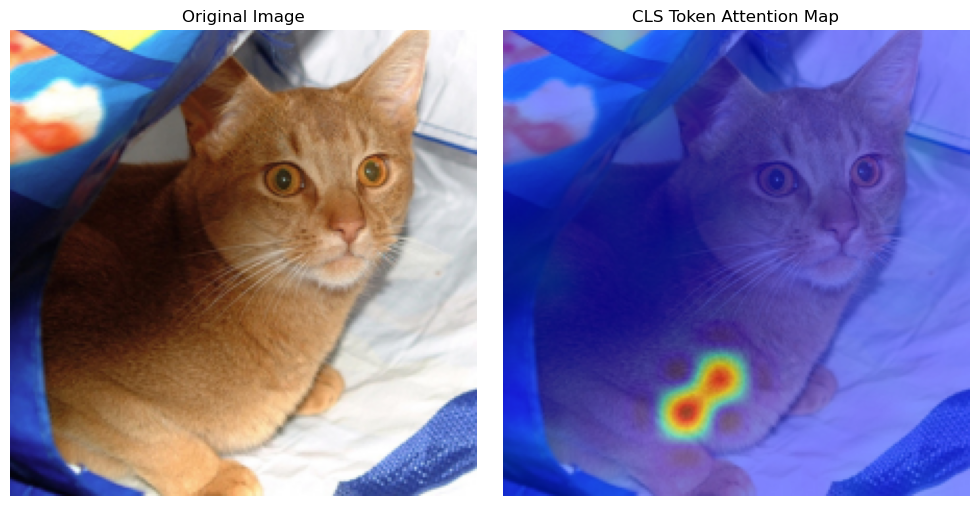

In [12]:
attn = attention_weights['last_layer_attn']
print(f"Attention shape: {attn.shape} -> (Batch, Heads, Seq_Len, Seq_Len)")

attn_mean = torch.mean(attn, dim=1).squeeze(0) # Shape: (197, 197)

# CLS token is at index 0. Image patches start at index 1. Display the attention from CLS token to all patches (excluding itself).
cls_attention = attn_mean[0, 1:] 

# Reshape the 196 flat sequence back into a 14x14 grid
cls_attention = cls_attention.reshape(14, 14).cpu().numpy()

# Resize the 14x14 attention map back to the original 224x224 image size using cubic interpolation
attn_resized = cv2.resize(cls_attention, (224, 224), interpolation=cv2.INTER_CUBIC)

attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())

# Create a heatmap overlay
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

original_img = img_tensor.permute(1, 2, 0).numpy()
ax[0].imshow(original_img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(original_img)
ax[1].imshow(attn_resized, cmap='jet', alpha=0.5)
ax[1].set_title('CLS Token Attention Map')
ax[1].axis('off')

plt.tight_layout()
plt.show()